# 作業：集成學習 Ensemble Learning 簡化練習

本作業改寫自 `6.ipynb` 的集成學習教材，使用桌遊資料集進行練習。

本作業會保留原教材的主要知識點，但每一類概念只選擇一個代表性做法，避免內容過多。

## 本作業練習重點

1. 認識集成學習的三種主要想法：Bagging、Boosting、Stacking。
2. 使用單一決策樹作為基準模型。
3. 使用 Bagging 與 Random Forest 理解平行集成。
4. 使用 AdaBoost 理解循序集成。
5. 使用 Soft Voting 理解投票法。
6. 使用 Stacking 理解兩層模型架構。
7. 使用 Accuracy 作為本作業唯一主要評估指標。
8. 使用視覺化檢查類別分布、模型比較結果、混淆矩陣與特徵重要性。

## 需要的檔案

請確認下列兩個 CSV 檔與本 notebook 放在同一個資料夾中：

- `details.csv`
- `ratings.csv`

# 一、資料集欄位說明

以下欄位說明是根據資料欄位名稱與資料內容整理而成，主要用於教學作業。

## `details.csv`

| 欄位名稱 | 說明 | 本作業是否使用 |
|---|---|---|
| `num` | 資料中的流水編號 | 否 |
| `id` | 桌遊唯一識別碼，可用來和 `ratings.csv` 合併 | 是，作為合併鍵 |
| `primary` | 桌遊主要名稱 | 否 |
| `description` | 桌遊文字描述 | 否，本作業先不處理文字資料 |
| `yearpublished` | 出版年份 | 是 |
| `minplayers` | 最少遊玩人數 | 是 |
| `maxplayers` | 最多遊玩人數 | 是 |
| `playingtime` | 預估遊玩時間 | 是 |
| `minplaytime` | 最短遊玩時間 | 是 |
| `maxplaytime` | 最長遊玩時間 | 是 |
| `minage` | 建議最低年齡 | 是 |
| `boardgamecategory` | 桌遊類別 | 否，本作業先不處理類別文字 |
| `boardgamemechanic` | 桌遊機制 | 否，本作業先不處理類別文字 |
| `boardgamefamily` | 桌遊系列或家族 | 否 |
| `boardgameexpansion` | 擴充資訊 | 否 |
| `boardgameimplementation` | 實作或版本資訊 | 否 |
| `boardgamedesigner` | 設計師 | 否 |
| `boardgameartist` | 美術設計 | 否 |
| `boardgamepublisher` | 出版商 | 否 |
| `owned` | 擁有此遊戲的使用者數量 | 是 |
| `trading` | 願意交換此遊戲的使用者數量 | 是 |
| `wanting` | 想要此遊戲的使用者數量 | 是 |
| `wishing` | 願望清單中包含此遊戲的使用者數量 | 是 |

## `ratings.csv`

| 欄位名稱 | 說明 | 本作業是否使用 |
|---|---|---|
| `num` | 資料中的流水編號 | 否 |
| `id` | 桌遊唯一識別碼，可用來和 `details.csv` 合併 | 是，作為合併鍵 |
| `name` | 桌遊名稱 | 否 |
| `year` | 出版年份 | 否，避免和 `yearpublished` 重複 |
| `rank` | 排名 | 否，可能與評分目標高度相關，先不使用 |
| `average` | 使用者平均評分 | 是，用來建立目標變數 |
| `bayes_average` | Bayesian average 評分 | 否，可能與目標高度相關，先不使用 |
| `users_rated` | 評分人數 | 是 |
| `url` | 桌遊頁面網址 | 否 |
| `thumbnail` | 圖片連結 | 否 |

# 二、簡化原則

原本教材包含多個模型、多個評估指標與多種分析方式。本作業為了適合學生練習，採用以下簡化策略：

| 原教材可能包含的內容 | 本作業的簡化方式 |
|---|---|
| 多個評估指標 | 只使用 Accuracy |
| 分類與迴歸都示範 | 只做分類任務 |
| 多種 Boosting 演算法 | 只使用 AdaBoost |
| Hard Voting、Soft Voting、Weighted Voting | 程式只實作 Soft Voting，其他以文字理解 |
| 多種資料分析方法 | 只加入必要視覺化與 Random Forest 特徵重要性 |
| 複雜特徵工程 | 只使用數值欄位 |

## 本作業的預測任務

我們將使用桌遊的基本資訊與使用者互動資料，預測該桌遊是否屬於「相對高評分」遊戲。

目標變數定義如下：

- `high_rating = 1`：`average` 大於或等於本作業資料的平均評分中位數。
- `high_rating = 0`：`average` 小於本作業資料的平均評分中位數。

使用中位數作為門檻的原因是：可以讓兩個類別比較平衡，較適合初學者用 Accuracy 觀察模型表現。

In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 設定字型 (有內建微軟正黑體)
import matplotlib.pyplot as plt

# 設定繪圖風格與字型，確保中文顯示正常
plt.style.use('fivethirtyeight')

# 設定字型為微軟正黑體，並確保數學符號正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 確保負號和數學符號正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

In [2]:
# ============================================================
# 0. 匯入套件
# ============================================================
# 本作業使用 pandas 處理表格資料。
# 使用 matplotlib 進行基礎視覺化。
# 使用 scikit-learn 建立機器學習模型。
#
# 注意：
# 本作業不使用 seaborn，避免學生環境沒有安裝。
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
# ============================================================
# 1. 讀取資料
# ============================================================
# 請確認 details.csv 與 ratings.csv 和本 notebook 放在同一個資料夾。
# ============================================================

details = pd.read_csv("details.csv")
ratings = pd.read_csv("ratings.csv")

# 移除欄位名稱前後可能存在的空白，避免後續選欄位時發生錯誤。
details.columns = details.columns.str.strip()
ratings.columns = ratings.columns.str.strip()

print("details 資料筆數與欄位數：", details.shape)
print("ratings 資料筆數與欄位數：", ratings.shape)

print("\ndetails 前 3 筆資料：")
display(details.head(3))

print("ratings 前 3 筆資料：")
display(ratings.head(3))

details 資料筆數與欄位數： (21631, 23)
ratings 資料筆數與欄位數： (21831, 10)

details 前 3 筆資料：


,num,id,primary,description,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,...,boardgamefamily,boardgameexpansion,boardgameimplementation,boardgamedesigner,boardgameartist,boardgamepublisher,owned,trading,wanting,wishing
0,0,30549,Pandemic,"In Pandemic, several virulent diseases have br...",2008,2,4,45,45,45,...,"['Components: Map (Global Scale)', 'Components...",['Pandemic: Gen Con 2016 Promos – Z-Force Team...,"['Pandemic Legacy: Season 0', 'Pandemic Legacy...",['Matt Leacock'],"['Josh Cappel', 'Christian Hanisch', 'Régis Mo...","['Z-Man Games', 'Albi', 'Asmodee', 'Asmodee It...",168364,2508,625,9344
1,1,822,Carcassonne,Carcassonne is a tile-placement game in which ...,2000,2,5,45,30,45,...,"['Cities: Carcassonne (France)', 'Components: ...","['20 Jahre Darmstadt Spielt', 'Apothecaries (f...","['The Ark of the Covenant', 'Carcassonne für 2...",['Klaus-Jürgen Wrede'],"['Doris Matthäus', 'Anne Pätzke', 'Chris Quill...","['Hans im Glück', '999 Games', 'Albi', 'Bard C...",161299,1716,582,7383
2,2,13,Catan,"In CATAN (formerly The Settlers of Catan), pla...",1995,3,4,120,60,120,...,"['Animals: Sheep', 'Components: Hexagonal Tile...","['20 Jahre Darmstadt Spielt', 'Brettspiel Adve...","['Baden-Württemberg Catan', 'Catan Geographies...",['Klaus Teuber'],"['Volkan Baga', 'Tanja Donner', 'Pete Fenlon',...","['KOSMOS', '999 Games', 'Albi', 'Asmodee', 'As...",167733,2018,485,5890


ratings 前 3 筆資料：


,num,id,name,year,rank,average,bayes_average,users_rated,url,thumbnail
0,105,30549,Pandemic,2008,106,7.59,7.487,108975,/boardgame/30549/pandemic,https://cf.geekdo-images.com/S3ybV1LAp-8SnHIXL...
1,189,822,Carcassonne,2000,190,7.42,7.309,108738,/boardgame/822/carcassonne,https://cf.geekdo-images.com/okM0dq_bEXnbyQTOv...
2,428,13,Catan,1995,429,7.14,6.970,108024,/boardgame/13/catan,https://cf.geekdo-images.com/W3Bsga_uLP9kO91gZ...


In [4]:
# ============================================================
# 2. 合併資料
# ============================================================
# details.csv 與 ratings.csv 都有 id 欄位。
# 因此可以用 id 將兩份資料合併成一份完整資料。
# ============================================================

df = pd.merge(
    details,
    ratings,
    on="id",
    how="inner",
    suffixes=("_details", "_ratings")
)

print("合併後資料筆數與欄位數：", df.shape)

print("合併後資料前 5 筆：")
display(df.head(5))

合併後資料筆數與欄位數： (21631, 32)
合併後資料前 5 筆：


,num_details,id,primary,description,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,...,wishing,num_ratings,name,year,rank,average,bayes_average,users_rated,url,thumbnail
0,0,30549,Pandemic,"In Pandemic, several virulent diseases have br...",2008,2,4,45,45,45,...,9344,105,Pandemic,2008,106,7.59,7.487,108975,/boardgame/30549/pandemic,https://cf.geekdo-images.com/S3ybV1LAp-8SnHIXL...
1,1,822,Carcassonne,Carcassonne is a tile-placement game in which ...,2000,2,5,45,30,45,...,7383,189,Carcassonne,2000,190,7.42,7.309,108738,/boardgame/822/carcassonne,https://cf.geekdo-images.com/okM0dq_bEXnbyQTOv...
2,2,13,Catan,"In CATAN (formerly The Settlers of Catan), pla...",1995,3,4,120,60,120,...,5890,428,Catan,1995,429,7.14,6.970,108024,/boardgame/13/catan,https://cf.geekdo-images.com/W3Bsga_uLP9kO91gZ...
3,3,68448,7 Wonders,You are the leader of one of the 7 great citie...,2010,2,7,30,30,30,...,12105,72,7 Wonders,2010,73,7.74,7.634,89982,/boardgame/68448/7-wonders,https://cf.geekdo-images.com/RvFVTEpnbb4NM7k0I...
4,4,36218,Dominion,"&quot;You are a monarch, like your parents bef...",2008,2,4,30,30,30,...,8621,103,Dominion,2008,104,7.61,7.499,81561,/boardgame/36218/dominion,https://cf.geekdo-images.com/j6iQpZ4XkemZP07HN...


In [5]:
# ============================================================
# 3. 基礎資料清理
# ============================================================
# yearpublished <= 0 通常代表年份不明或不合理。
# average <= 0 對本作業的評分分類沒有幫助。
#
# 為了讓學生執行速度穩定，本作業只抽樣 1500 筆資料。
# 若想使用完整資料，可以把 sample_size 改大，或註解掉抽樣區塊。
# ============================================================

df = df[df["yearpublished"] > 0].copy()
df = df[df["average"] > 0].copy()

sample_size = 1500

if df.shape[0] > sample_size:
    df = df.sample(n=sample_size, random_state=42).copy()

print("清理與抽樣後資料筆數與欄位數：", df.shape)

清理與抽樣後資料筆數與欄位數： (1500, 32)


In [6]:
# ============================================================
# 4. 建立目標變數 high_rating
# ============================================================
# 本作業使用 average 的中位數當作門檻。
#
# high_rating = 1：平均評分大於或等於中位數
# high_rating = 0：平均評分小於中位數
# ============================================================

rating_threshold = df["average"].median()
df["high_rating"] = 0

df.loc[df["average"] >= rating_threshold, "high_rating"] = 1

print("本作業使用的 average 中位數門檻：", rating_threshold)
print("\nhigh_rating 類別分布：")
print(df["high_rating"].value_counts())

本作業使用的 average 中位數門檻： 6.41

high_rating 類別分布：
high_rating
1    756
0    744
Name: count, dtype: int64


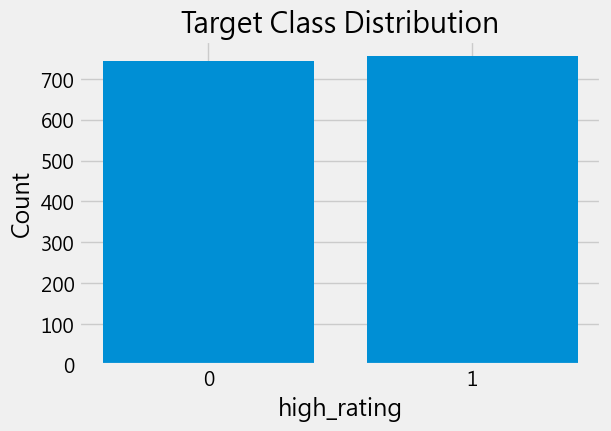

In [7]:
# ============================================================
# 5. 視覺化：檢查目標類別分布
# ============================================================
# 這張圖可以幫助我們確認 high_rating = 0 與 high_rating = 1
# 是否大致平衡。
# ============================================================

class_counts = df["high_rating"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("high_rating")
plt.ylabel("Count")
plt.title("Target Class Distribution")
plt.show()

In [8]:
# ============================================================
# 6. 選擇特徵欄位
# ============================================================
# 本作業只使用數值欄位，避免文字處理造成作業太複雜。
#
# 注意：
# average 是用來建立答案的欄位，所以不能放入 X。
# bayes_average 與 rank 和評分高度相關，本作業也先不放入 X，避免任務過於簡單。
# ============================================================

feature_cols = [
    "yearpublished",
    "minplayers",
    "maxplayers",
    "playingtime",
    "minplaytime",
    "maxplaytime",
    "minage",
    "owned",
    "trading",
    "wanting",
    "wishing",
    "users_rated"
]

required_cols = feature_cols.copy()
required_cols.append("high_rating")

missing_cols = []

for col in required_cols:
    if col not in df.columns:
        missing_cols.append(col)

if len(missing_cols) > 0:
    raise ValueError("資料集中缺少以下必要欄位：" + str(missing_cols))

X = df[feature_cols].copy()
y = df["high_rating"].copy()

print("特徵資料 X 的大小：", X.shape)
print("目標變數 y 的大小：", y.shape)

print("\n本作業使用的特徵欄位：")
for col in feature_cols:
    print("-", col)

特徵資料 X 的大小： (1500, 12)
目標變數 y 的大小： (1500,)

本作業使用的特徵欄位：
- yearpublished
- minplayers
- maxplayers
- playingtime
- minplaytime
- maxplaytime
- minage
- owned
- trading
- wanting
- wishing
- users_rated


In [9]:
# ============================================================
# 7. 切分訓練集與測試集
# ============================================================
# stratify=y：讓訓練集與測試集中的類別比例盡量接近原始資料。
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train：", X_train.shape)
print("X_test ：", X_test.shape)
print("y_train：", y_train.shape)
print("y_test ：", y_test.shape)

X_train： (1200, 12)
X_test ： (300, 12)
y_train： (1200,)
y_test ： (300,)


# 三、模型訓練

以下所有模型都使用同一份訓練集與測試集，並且都使用 Accuracy 比較表現。

## 3.1 基準模型：單一決策樹

單一決策樹容易理解，也常用來和集成學習方法比較。

缺點是：如果樹長得太深，容易過度配合訓練資料，也就是過擬合。

In [10]:
# ============================================================
# 8. 建立基準模型：單一決策樹
# ============================================================
# max_depth 用來限制樹的深度，避免模型過度複雜。
# ============================================================

single_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

single_tree_model.fit(X_train, y_train)

single_tree_train_pred = single_tree_model.predict(X_train)
single_tree_test_pred = single_tree_model.predict(X_test)

single_tree_train_acc = accuracy_score(y_train, single_tree_train_pred)
single_tree_test_acc = accuracy_score(y_test, single_tree_test_pred)

print("單一決策樹訓練集 Accuracy：", single_tree_train_acc)
print("單一決策樹測試集 Accuracy：", single_tree_test_acc)

單一決策樹訓練集 Accuracy： 0.8083333333333333
單一決策樹測試集 Accuracy： 0.7533333333333333


## 3.2 Bagging：平行訓練多個模型再整合

Bagging 是 Bootstrap Aggregating 的縮寫。

- Bootstrap：從訓練資料中進行有放回抽樣。
- Aggregating：把多個模型的結果整合起來。

分類問題通常使用投票，迴歸問題通常使用平均。

本作業使用多個決策樹組成 Bagging 模型。

In [11]:
# ============================================================
# 9. BaggingClassifier
# ============================================================
# 這裡使用決策樹作為 Bagging 的基礎模型。
# n_estimators 代表要建立幾個基礎模型。
# ============================================================

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=42),
    n_estimators=10,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_train_pred = bagging_model.predict(X_train)
bagging_test_pred = bagging_model.predict(X_test)

bagging_train_acc = accuracy_score(y_train, bagging_train_pred)
bagging_test_acc = accuracy_score(y_test, bagging_test_pred)

print("Bagging 訓練集 Accuracy：", bagging_train_acc)
print("Bagging 測試集 Accuracy：", bagging_test_acc)

Bagging 訓練集 Accuracy： 0.8275
Bagging 測試集 Accuracy： 0.7766666666666666


## 3.3 Random Forest：Bagging 的代表性演算法

Random Forest 可以視為 Bagging 的延伸。

它不只會抽樣資料，也會在每棵樹分裂節點時抽樣特徵，讓每棵樹之間更不一樣。

這種隨機性通常可以降低單一決策樹的變異，讓模型比較穩定。

In [12]:
# ============================================================
# 10. Random Forest
# ============================================================
# n_estimators：森林中樹的數量。
# max_depth：限制每棵樹的最大深度。
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=5,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_train_pred = random_forest_model.predict(X_train)
random_forest_test_pred = random_forest_model.predict(X_test)

random_forest_train_acc = accuracy_score(y_train, random_forest_train_pred)
random_forest_test_acc = accuracy_score(y_test, random_forest_test_pred)

print("Random Forest 訓練集 Accuracy：", random_forest_train_acc)
print("Random Forest 測試集 Accuracy：", random_forest_test_acc)

Random Forest 訓練集 Accuracy： 0.86
Random Forest 測試集 Accuracy： 0.7733333333333333


## 3.4 Boosting：讓後面的模型修正前面的錯誤

Boosting 會循序訓練多個弱模型。

後面的模型會更重視前面模型預測錯誤的樣本，因此整體模型會逐步修正錯誤。

本作業只示範 AdaBoost，並使用深度為 1 的決策樹作為弱模型。

In [13]:
# ============================================================
# 11. AdaBoost
# ============================================================
# max_depth=1 的決策樹通常稱為 decision stump。
# 它是 AdaBoost 常用的弱模型。
# ============================================================

adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=20,
    learning_rate=0.5,
    random_state=42
)

adaboost_model.fit(X_train, y_train)

adaboost_train_pred = adaboost_model.predict(X_train)
adaboost_test_pred = adaboost_model.predict(X_test)

adaboost_train_acc = accuracy_score(y_train, adaboost_train_pred)
adaboost_test_acc = accuracy_score(y_test, adaboost_test_pred)

print("AdaBoost 訓練集 Accuracy：", adaboost_train_acc)
print("AdaBoost 測試集 Accuracy：", adaboost_test_acc)

AdaBoost 訓練集 Accuracy： 0.7691666666666667
AdaBoost 測試集 Accuracy： 0.7166666666666667


## 3.5 Voting：多個模型一起投票

Voting 會把多個不同模型的預測結果整合起來。

常見做法有三種：

1. Hard Voting：每個模型投一票，得票最多的類別勝出。
2. Soft Voting：平均各模型的預測機率，機率最高的類別勝出。
3. Weighted Soft Voting：和 Soft Voting 類似，但可以給不同模型不同權重。

本作業只實作 Soft Voting，因為它是常見且容易理解的版本。

此外，Logistic Regression 與 KNN 對特徵尺度比較敏感，因此這裡示範使用 Pipeline 加入 StandardScaler。

In [14]:
# ============================================================
# 12. Soft Voting
# ============================================================
# 這裡整合三個模型：
# 1. Logistic Regression：線性模型，需要標準化
# 2. KNN：距離型模型，需要標準化
# 3. Random Forest：樹模型，不一定需要標準化
#
# Pipeline 的用途：
# 把資料前處理和模型包在一起，避免訓練與測試流程不一致。
# ============================================================

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=11))
])

rf_for_voting = RandomForestClassifier(
    n_estimators=20,
    max_depth=5,
    random_state=42
)

soft_voting_model = VotingClassifier(
    estimators=[
        ("logistic", logistic_pipeline),
        ("knn", knn_pipeline),
        ("random_forest", rf_for_voting)
    ],
    voting="soft"
)

soft_voting_model.fit(X_train, y_train)

soft_voting_train_pred = soft_voting_model.predict(X_train)
soft_voting_test_pred = soft_voting_model.predict(X_test)

soft_voting_train_acc = accuracy_score(y_train, soft_voting_train_pred)
soft_voting_test_acc = accuracy_score(y_test, soft_voting_test_pred)

print("Soft Voting 訓練集 Accuracy：", soft_voting_train_acc)
print("Soft Voting 測試集 Accuracy：", soft_voting_test_acc)

Soft Voting 訓練集 Accuracy： 0.8425
Soft Voting 測試集 Accuracy： 0.7733333333333333


## 3.6 Stacking：讓第二層模型學習如何整合第一層模型

Stacking 和 Voting 不同。

- Voting：直接用投票或平均機率整合模型。
- Stacking：先讓第一層模型做預測，再把第一層模型的預測結果交給第二層模型學習如何整合。

本作業使用：

- 第一層模型：Logistic Regression 與 Decision Tree。
- 第二層模型：Logistic Regression。

In [15]:
# ============================================================
# 13. Stacking
# ============================================================
# cv=2 代表使用 2-fold cross-validation 建立第二層訓練資料。
# 為了讓課堂執行速度較快，本作業使用較小的 cv。
# ============================================================

stacking_base_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

stacking_base_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

stacking_model = StackingClassifier(
    estimators=[
        ("logistic", stacking_base_logistic),
        ("tree", stacking_base_tree)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=2
)

stacking_model.fit(X_train, y_train)

stacking_train_pred = stacking_model.predict(X_train)
stacking_test_pred = stacking_model.predict(X_test)

stacking_train_acc = accuracy_score(y_train, stacking_train_pred)
stacking_test_acc = accuracy_score(y_test, stacking_test_pred)

print("Stacking 訓練集 Accuracy：", stacking_train_acc)
print("Stacking 測試集 Accuracy：", stacking_test_acc)

Stacking 訓練集 Accuracy： 0.815
Stacking 測試集 Accuracy： 0.77


# 四、模型比較與視覺化

本作業只使用 Accuracy 作為主要評估指標。

我們會比較每個模型的訓練集 Accuracy 與測試集 Accuracy。

如果訓練集 Accuracy 很高，但測試集 Accuracy 明顯較低，通常代表模型可能有過擬合現象。

In [16]:
# ============================================================
# 14. 整理模型比較表
# ============================================================
# 這裡建立一個 DataFrame，方便後續排序與畫圖。
# ============================================================

results = []

results.append({
    "model": "Single Decision Tree",
    "train_accuracy": single_tree_train_acc,
    "test_accuracy": single_tree_test_acc
})

results.append({
    "model": "Bagging Decision Tree",
    "train_accuracy": bagging_train_acc,
    "test_accuracy": bagging_test_acc
})

results.append({
    "model": "Random Forest",
    "train_accuracy": random_forest_train_acc,
    "test_accuracy": random_forest_test_acc
})

results.append({
    "model": "AdaBoost",
    "train_accuracy": adaboost_train_acc,
    "test_accuracy": adaboost_test_acc
})

results.append({
    "model": "Soft Voting",
    "train_accuracy": soft_voting_train_acc,
    "test_accuracy": soft_voting_test_acc
})

results.append({
    "model": "Stacking",
    "train_accuracy": stacking_train_acc,
    "test_accuracy": stacking_test_acc
})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="test_accuracy", ascending=False)

print("模型比較結果：")
display(results_df)

模型比較結果：


,model,train_accuracy,test_accuracy
1,Bagging Decision Tree,0.827500,0.776667
2,Random Forest,0.860000,0.773333
4,Soft Voting,0.842500,0.773333
5,Stacking,0.815000,0.770000
0,Single Decision Tree,0.808333,0.753333
3,AdaBoost,0.769167,0.716667


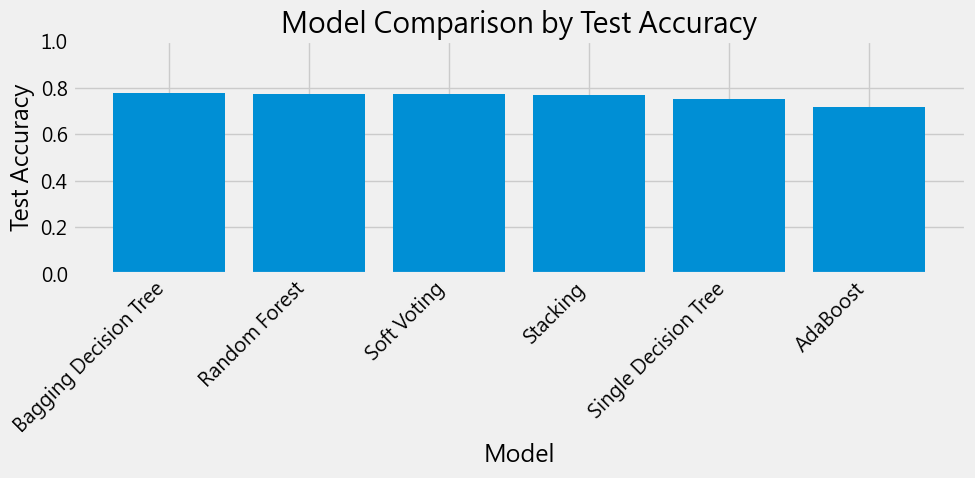

In [17]:
# ============================================================
# 15. 視覺化：比較模型測試集 Accuracy
# ============================================================
# 這張圖可以幫助我們快速看出哪一個模型在測試集表現最好。
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_accuracy"])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Model Comparison by Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 16. 找出測試集 Accuracy 最高的模型
# ============================================================
# 這裡用 if / elif 的方式取得最佳模型物件，避免使用較進階的寫法。
# ============================================================

best_model_name = results_df.iloc[0]["model"]
print("測試集 Accuracy 最高的模型：", best_model_name)

best_model = None
best_test_pred = None

if best_model_name == "Single Decision Tree":
    best_model = single_tree_model
    best_test_pred = single_tree_test_pred
elif best_model_name == "Bagging Decision Tree":
    best_model = bagging_model
    best_test_pred = bagging_test_pred
elif best_model_name == "Random Forest":
    best_model = random_forest_model
    best_test_pred = random_forest_test_pred
elif best_model_name == "AdaBoost":
    best_model = adaboost_model
    best_test_pred = adaboost_test_pred
elif best_model_name == "Soft Voting":
    best_model = soft_voting_model
    best_test_pred = soft_voting_test_pred
elif best_model_name == "Stacking":
    best_model = stacking_model
    best_test_pred = stacking_test_pred
else:
    raise ValueError("找不到對應的最佳模型。")

測試集 Accuracy 最高的模型： Bagging Decision Tree


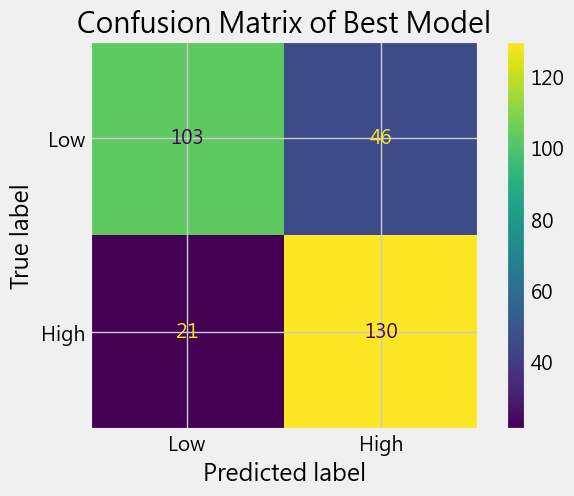

In [19]:
# ============================================================
# 17. 視覺化：最佳模型的混淆矩陣
# ============================================================
# 混淆矩陣可以幫助我們觀察：
# 1. 哪些類別被正確分類
# 2. 哪些類別容易被模型混淆
# ============================================================

cm = confusion_matrix(y_test, best_test_pred)

display_labels = ["Low", "High"]

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
).plot()

plt.title("Confusion Matrix of Best Model")
plt.show()

# 五、特徵重要性

許多樹模型可以提供特徵重要性，幫助我們初步理解模型判斷時較重視哪些欄位。

本作業只使用 Random Forest 的特徵重要性作為代表。

注意：特徵重要性只能作為初步參考，不代表因果關係。

In [20]:
# ============================================================
# 18. Random Forest 特徵重要性
# ============================================================
# feature_importances_ 代表 Random Forest 對每個特徵的重要性估計。
# ============================================================

importance_df = pd.DataFrame()
importance_df["feature"] = feature_cols
importance_df["importance"] = random_forest_model.feature_importances_
importance_df = importance_df.sort_values(by="importance", ascending=False)

print("Random Forest 特徵重要性：")
display(importance_df)

Random Forest 特徵重要性：


,feature,importance
9,wanting,0.276376
10,wishing,0.168916
0,yearpublished,0.155841
8,trading,0.097559
5,maxplaytime,0.095115
7,owned,0.049947
11,users_rated,0.049651
3,playingtime,0.031215
4,minplaytime,0.025164
6,minage,0.022236


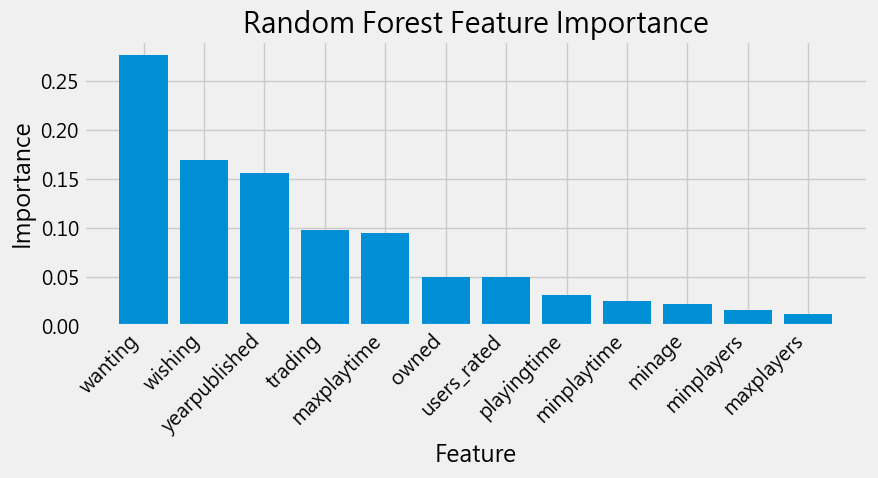

In [21]:
# ============================================================
# 19. 視覺化：Random Forest 特徵重要性
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 六、作業問題

請同學完成以下問題，並將答案寫在 notebook 的 Markdown cell 中。

## 問題 1：資料理解

1. 本作業的目標變數 `high_rating` 是如何建立的？
2. 為什麼本作業不把 `average` 放入模型特徵？
3. 為什麼本作業不把 `rank` 與 `bayes_average` 放入模型特徵？

## 問題 2：模型概念

請用自己的話簡短說明下列方法的差異：

1. Bagging
2. Random Forest
3. Boosting
4. Soft Voting
5. Stacking

## 問題 3：模型比較

1. 哪一個模型的測試集 Accuracy 最高？
2. 單一決策樹和集成模型相比，哪一個比較好？
3. 有沒有模型出現訓練集 Accuracy 明顯高於測試集 Accuracy 的情況？這可能代表什麼？

## 問題 4：視覺化解讀

1. 從混淆矩陣來看，模型比較容易預測錯哪一類？
2. 從 Random Forest 特徵重要性來看，哪些欄位對模型比較重要？
3. 你認為這些重要欄位是否合理？請簡短說明。

## 問題 5：延伸練習

請選擇其中一個模型，改變一個參數，再重新執行模型。

例如：

- 將 Random Forest 的 `n_estimators` 從 20 改成 50。
- 將 Decision Tree 的 `max_depth` 從 4 改成 6。
- 將 KNN 的 `n_neighbors` 從 11 改成 5。

請記錄修改前後的測試集 Accuracy，並簡短說明結果是否有改善。